# English Variants Sentiment and Sarcasm

This notebook compares classical and transformer classifiers across British, Australian, and Indian English, then examines transfer, multilingual modelling, errors, and explanations.


## Dataset and Linguistic Analysis

Class balance, vocabulary markers, and tokenisation behaviour by English variety.


In [1]:
# Cell 1 — Install (run once at top of notebook)
!pip install datasets wordcloud transformers --quiet

In [2]:

# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
from wordcloud import WordCloud
import re, warnings
warnings.filterwarnings('ignore')


In [3]:
# Cell 3 — Load dataset
ds = load_dataset('surrey-nlp/BESSTIE-CW-26')
print(ds)         # shows splits: train / validation / test
print(ds['train'][:5])  # look at ONE example together

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})
{'text': ["I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.", 'Yeah it blew out to 3x what it was budgeted for. Who wouldve thought giving people free cash to reovate their house would dry up resources for new builds...', 'Food was pretty great. A little dry, but I am a sucker for a load of dressing. Drinks were great. Wait staff were super attentive when we first got there but then kinda lost interest

In [4]:
# Convert splits to pandas DataFrames
df_train = pd.DataFrame(ds['train'])
df_val = pd.DataFrame(ds['validation'])
df_test = pd.DataFrame(ds['test'])

print(df_train.head())
print(df_train.columns)

                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  
3        0.0      0.0  
4        1.0      0.0  
Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm'], dtype='object')


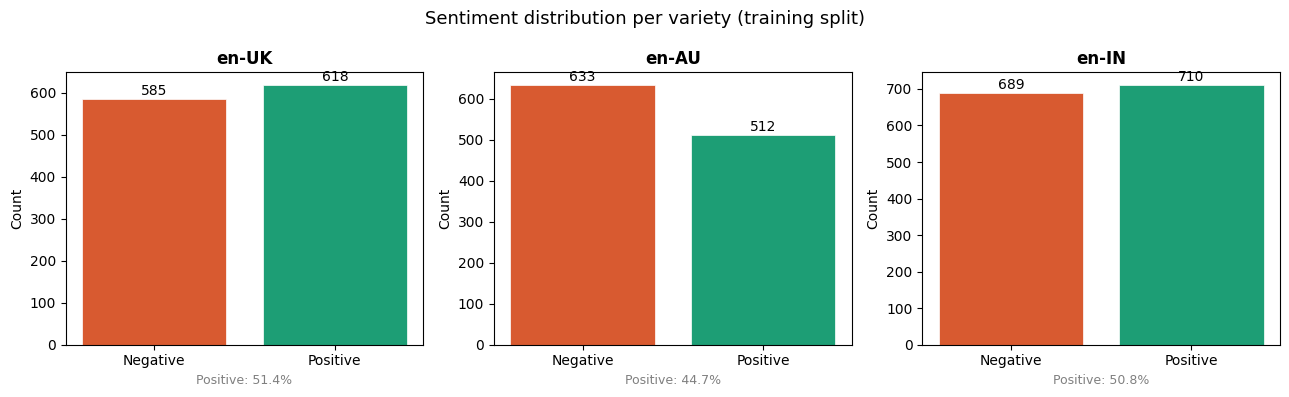

In [5]:
# Cell 5 — Sentiment distribution per variety
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Sentiment distribution per variety (training split)', fontsize=13)

sent_map = {0:'Negative', 1:'Positive'}
sent_colors = ['#D85A30','#1D9E75']
VARIETIES = ['en-UK', 'en-AU', 'en-IN']



for ax, variety in zip(axes, VARIETIES):
    sub = df_train[df_train['variety'] == variety]
    counts = sub['Sentiment'].value_counts().sort_index()
    labels = [sent_map[i] for i in counts.index]

    bars = ax.bar(labels, counts.values, color=sent_colors,
                  edgecolor='white', linewidth=0.5)
    ax.set_title(variety, fontweight='bold')
    ax.set_ylabel('Count')

    # Add count labels on top of bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+3, str(val),
                ha='center', va='bottom', fontsize=10)

    # Show % positive
    pct = counts.get(1,0)/counts.sum()*100
    ax.set_xlabel(f'Positive: {pct:.1f}%', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig('q1_sentiment_dist.png', bbox_inches='tight')
plt.show()

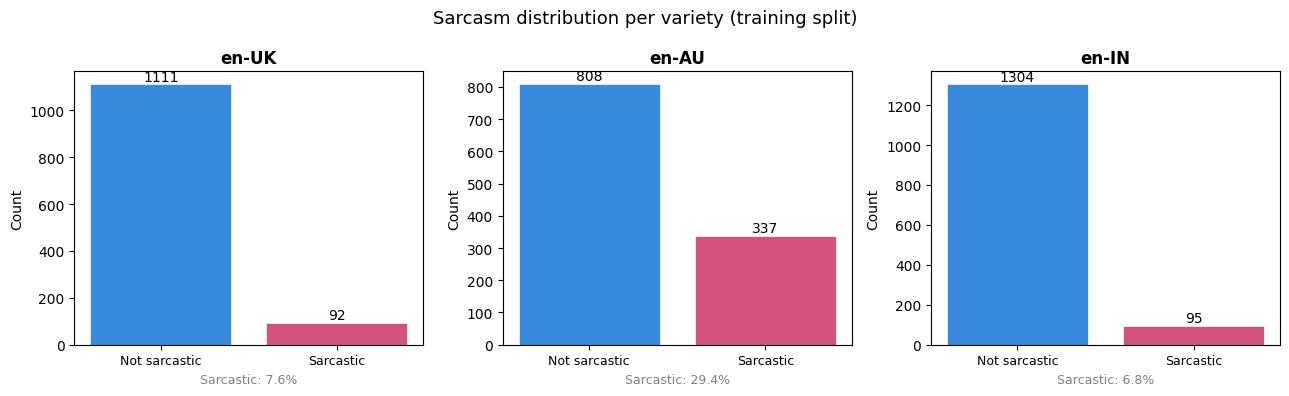

In [6]:
# Cell 6 — Sarcasm distribution per variety

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Sarcasm distribution per variety (training split)', fontsize=13)

sarc_map = {0:'Not sarcastic', 1:'Sarcastic'}
sarc_colors = ['#378ADD','#D4537E']

for ax, variety in zip(axes, VARIETIES):
    sub = df_train[df_train['variety'] == variety]
    counts = sub['Sarcasm'].value_counts().sort_index()
    labels = [sarc_map[i] for i in counts.index]

    bars = ax.bar(labels, counts.values, color=sarc_colors,
                  edgecolor='white', linewidth=0.5)
    ax.set_title(variety, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', labelsize=9)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+3, str(val),
                ha='center', va='bottom', fontsize=10)

    pct = counts.get(1,0)/counts.sum()*100
    ax.set_xlabel(f'Sarcastic: {pct:.1f}%', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig('q1_sarcasm_dist.png', bbox_inches='tight')
plt.show()


In [7]:
print(df_train.groupby('variety')['Sentiment'].value_counts())
print(df_train.groupby('variety')['Sarcasm'].value_counts())
print(df_train.groupby('variety')[['Sentiment', 'Sarcasm']].mean())

variety  Sentiment
en-AU    0.0          633
         1.0          512
en-IN    1.0          710
         0.0          689
en-UK    1.0          618
         0.0          585
Name: count, dtype: int64
variety  Sarcasm
en-AU    0.0         808
         1.0         337
en-IN    0.0        1304
         1.0          95
en-UK    0.0        1111
         1.0          92
Name: count, dtype: int64
         Sentiment   Sarcasm
variety                     
en-AU     0.447162  0.294323
en-IN     0.507505  0.067906
en-UK     0.513716  0.076475


In [8]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

def simple_tokenize(text):
    doc = nlp(str(text).lower())
    # return [token.text for token in doc if token.is_alpha]
    return [
        token.lemma_          # lemmatised form
        for token in doc
        if token.is_alpha         # real words only
        and not token.is_stop     # remove stopwords
        and len(token.text) >= 3  # remove single/double char artifacts
    ]

In [9]:
COLORS     = {'en-AU': '#4C72B0', 'en-IN': '#DD8452', 'en-UK': '#55A868'}
CMAPS      = {'en-AU': 'Blues',   'en-IN': 'Oranges', 'en-UK': 'Greens'}

freqs = {}
for variety in VARIETIES:
    texts  = df_train[df_train['variety'] == variety]['text'].tolist()
    tokens = []
    for t in texts:
        tokens.extend(simple_tokenize(t))
    freqs[variety] = Counter(tokens)
    print(f"{variety}: {len(tokens)} total tokens | {len(freqs[variety])} unique")

en-UK: 32351 total tokens | 5569 unique
en-AU: 28478 total tokens | 5955 unique
en-IN: 24636 total tokens | 5621 unique


In [10]:
def get_markers(target_v, top_n=20):
    """
    Score each word by how distinctive it is to target_v
    vs the other two varieties combined.
    distinctiveness = freq_in_target / freq_in_others
    """
    target  = freqs[target_v]
    others  = [freqs[v] for v in VARIETIES if v != target_v]
    total_t = sum(target.values())
    total_o = sum(sum(c.values()) for c in others)

    scores = {}
    for word, count in target.items():
        if count < 3:
            continue
        tf = count / total_t
        of = sum(c.get(word, 0) for c in others) / (total_o + 1)
        scores[word] = tf / (of + 1e-8)

    return sorted(scores.items(), key=lambda x: -x[1])[:top_n]

# Quick test
print("Top 5 markers per variety:")
for v in VARIETIES:
    print(f"  {v}: {[w for w, s in get_markers(v, 5)]}")

Top 5 markers per variety:
  en-UK: ['tory', 'ale', 'wetherspoon', 'pint', 'starmer']
  en-AU: ['labor', 'australian', 'melbourne', 'sydney', 'nuclear']
  en-IN: ['hai', 'dosa', 'thali', 'toh', 'biriyani']


In [11]:
unique_tokens = {}

for variety in VARIETIES:
    other_varieties = [v for v in VARIETIES if v != variety]
    unique_tokens[variety] = {}

    for word, count in freqs[variety].items():
        present_elsewhere = False

        for other in other_varieties:
            if freqs[other][word] > 0:
                present_elsewhere = True
                break

        if not present_elsewhere and count >= 3:
            unique_tokens[variety][word] = count

for variety in VARIETIES:
    print(f"\nUnique tokens for {variety}:")
    sorted_unique = sorted(unique_tokens[variety].items(), key=lambda x: x[1], reverse=True)
    print(sorted_unique[:20])


Unique tokens for en-UK:
[('tory', 34), ('ale', 19), ('wetherspoon', 17), ('pint', 16), ('starmer', 13), ('england', 13), ('nhs', 12), ('swap', 10), ('costa', 10), ('acceptable', 10), ('inn', 9), ('sainsbury', 9), ('portuguese', 8), ('dem', 7), ('pound', 7), ('tray', 7), ('football', 7), ('coleslaw', 7), ('scenery', 7), ('utility', 6)]

Unique tokens for en-AU:
[('labor', 46), ('australian', 45), ('melbourne', 36), ('sydney', 29), ('nuclear', 22), ('adelaide', 20), ('brisbane', 15), ('coalition', 15), ('lnp', 15), ('helmet', 15), ('dutton', 14), ('federal', 14), ('dumpling', 11), ('birth', 11), ('queensland', 10), ('objective', 10), ('coal', 10), ('occupation', 10), ('coast', 10), ('nsw', 9)]

Unique tokens for en-IN:
[('hai', 54), ('dosa', 36), ('thali', 35), ('toh', 24), ('biriyani', 18), ('bjp', 17), ('bhi', 17), ('modi', 14), ('nahi', 13), ('bollywood', 13), ('kya', 13), ('punjabi', 13), ('temple', 12), ('mein', 11), ('dal', 11), ('parotta', 10), ('kachori', 10), ('sabji', 10), ('

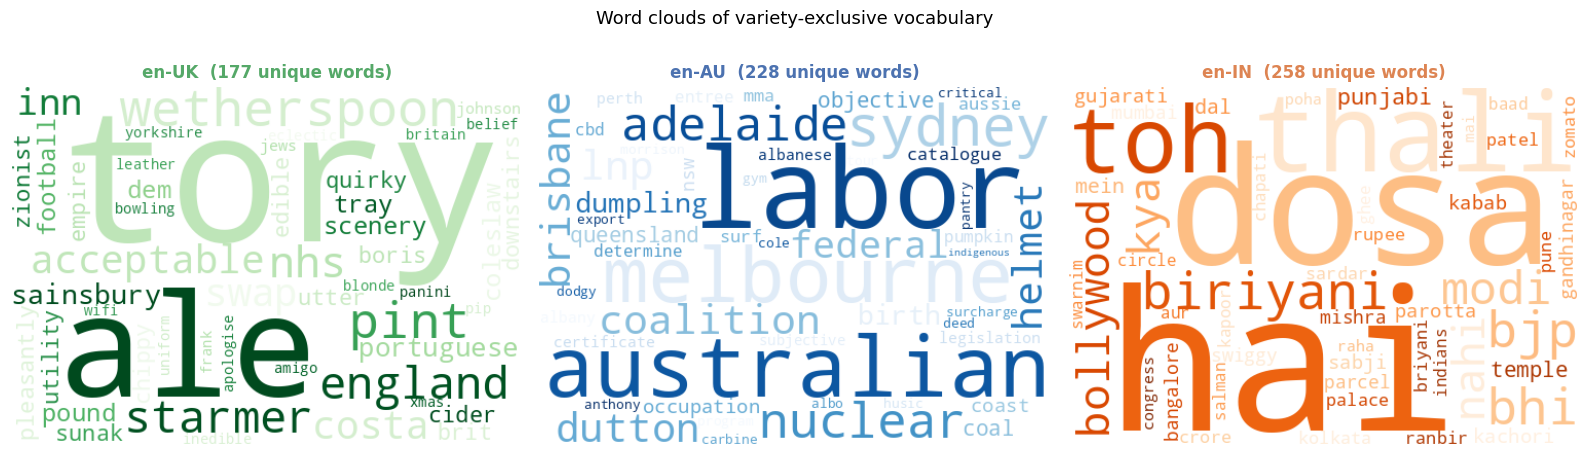

Saved: q1_unique_tokens_wordcloud.png


In [12]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Word clouds of variety-exclusive vocabulary', fontsize=13)

for ax, variety in zip(axes, VARIETIES):
    if not unique_tokens[variety]:
        ax.text(0.5, 0.5, 'No unique tokens', ha='center',
                va='center', transform=ax.transAxes)
        ax.axis('off')
        ax.set_title(variety)
        continue

    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap=CMAPS[variety],
        max_words=50,
        prefer_horizontal=0.8
    ).generate_from_frequencies(unique_tokens[variety])

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{variety}  ({len(unique_tokens[variety])} unique words)',
                 fontweight='bold', color=COLORS[variety], fontsize=12)

plt.tight_layout()
plt.savefig('q1_unique_tokens_wordcloud.png', bbox_inches='tight')
plt.show()
print('Saved: q1_unique_tokens_wordcloud.png')

In [13]:
# Print a clean summary table — paste this into your report
print("=" * 55)
print(f"{'Variety':<10} {'Unique words':>14} {'Top 5 examples'}")
print("=" * 55)

for variety in VARIETIES:
    sorted_unique = sorted(unique_tokens[variety].items(),
                           key=lambda x: x[1], reverse=True)
    n     = len(unique_tokens[variety])
    top5  = ', '.join([w for w, c in sorted_unique[:5]])
    print(f"{variety:<10} {n:>14}    {top5}")

print("=" * 55)

Variety      Unique words Top 5 examples
en-UK                 177    tory, ale, wetherspoon, pint, starmer
en-AU                 228    labor, australian, melbourne, sydney, nuclear
en-IN                 258    hai, dosa, thali, toh, biriyani


In [14]:
chosen_markers = {
    'en-UK': ['tories', 'wetherspoons', 'pint', 'nhs', 'starmer'],
    'en-AU': ['labor', 'melbourne', 'sydney', 'lnp', 'queensland'],
    'en-IN': ['hai', 'dosa', 'thali', 'toh', 'nahi']
}

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

for variety, words in chosen_markers.items():
    print(f"\n{variety}")
    for word in words:
        pieces = tokenizer.tokenize(word)
        print(f"{word:15s} -> {pieces}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


en-UK
tories          -> ['t', 'ories']
wetherspoons    -> ['w', 'ether', 'sp', 'oons']
pint            -> ['p', 'int']
nhs             -> ['n', 'hs']
starmer         -> ['star', 'mer']

en-AU
labor           -> ['l', 'abor']
melbourne       -> ['mel', 'bourne']
sydney          -> ['sy', 'd', 'ney']
lnp             -> ['ln', 'p']
queensland      -> ['que', 'ens', 'land']

en-IN
hai             -> ['hai']
dosa            -> ['d', 'osa']
thali           -> ['th', 'ali']
toh             -> ['t', 'oh']
nahi            -> ['n', 'ahi']


In [16]:
print(VARIETIES)

['en-UK', 'en-AU', 'en-IN']


## Classical and Transformer Baselines

TF-IDF logistic regression is compared with fine-tuned RoBERTa.


In [17]:
# Baseline comparison — Install and imports
!pip install transformers scikit-learn torch --quiet
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
from sklearn.metrics import precision_score, recall_score


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cpu':
    print('WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU')

Device: cuda


In [18]:
# Prepare texts and labels for both tasks
train_texts = df_train['text'].astype(str).tolist()
val_texts   = df_val['text'].astype(str).tolist()
test_texts  = df_test['text'].astype(str).tolist()

LABEL_COLS = {'sentiment': 'Sentiment', 'sarcasm': 'Sarcasm'}
SEEDS      = [42, 123]

labels = {}
for task, col in LABEL_COLS.items():
    labels[task] = {
        'train': df_train[col].astype(int).tolist(),
        'val':   df_val[col].astype(int).tolist(),
        'test':  df_test[col].astype(int).tolist()
    }

print(f'Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}')
for task in ['sentiment', 'sarcasm']:
    dist = {0: labels[task]['train'].count(0), 1: labels[task]['train'].count(1)}
    print(f'{task} train: {dist}')

Train: 3747 | Val: 313 | Test: 2183
sentiment train: {0: 1907, 1: 1840}
sarcasm train: {0: 3223, 1: 524}


In [19]:
# TF-IDF + Logistic Regression baseline function
def run_baseline(train_texts, train_labels, val_texts, val_labels,
                 seed=42, task='sentiment'):
    vectorizer = TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),   # unigrams + bigrams ("not great" as one feature)
        sublinear_tf=True     # log-normalise term frequencies
    )
    X_train = vectorizer.fit_transform(train_texts)
    X_val   = vectorizer.transform(val_texts)

    clf = LogisticRegression(
        class_weight='balanced',  # compensates for class imbalance (found in Q1)
        max_iter=1000,
        random_state=seed
    )
    clf.fit(X_train, train_labels)
    preds    = clf.predict(X_val)
    macro_f1 = f1_score(val_labels, preds, average='macro')

    print(f'Seed {seed} | Task: {task} | Macro-F1: {macro_f1:.4f}')
    print(classification_report(val_labels, preds,
                                target_names=['Neg/NotSarc', 'Pos/Sarc'],
                                digits=3))
    return macro_f1, preds, clf, vectorizer

In [20]:
# Run baseline — both tasks × 2 seeds
baseline_results = {}

for task in ['sentiment', 'sarcasm']:
    print(f"\n{'='*50}")
    print(f'BASELINE — {task.upper()}')
    print('='*50)

    f1_scores, best_preds = [], None

    for seed in SEEDS:
        f1, preds, clf, vec = run_baseline(
            train_texts, labels[task]['train'],
            val_texts,   labels[task]['val'],
            seed=seed, task=task
        )
        f1_scores.append(f1)
        if best_preds is None:
            best_preds = preds

    baseline_results[task] = {
        'mean_f1': np.mean(f1_scores),
        'std_f1':  np.std(f1_scores),
        'scores':  f1_scores,
        'preds':   best_preds
    }
    print(f'\n→ {task} Mean Macro-F1: '
          f'{np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')


BASELINE — SENTIMENT
Seed 42 | Task: sentiment | Macro-F1: 0.8530
              precision    recall  f1-score   support

 Neg/NotSarc      0.875     0.831     0.853       160
    Pos/Sarc      0.832     0.876     0.854       153

    accuracy                          0.853       313
   macro avg      0.854     0.854     0.853       313
weighted avg      0.854     0.853     0.853       313

Seed 123 | Task: sentiment | Macro-F1: 0.8530
              precision    recall  f1-score   support

 Neg/NotSarc      0.875     0.831     0.853       160
    Pos/Sarc      0.832     0.876     0.854       153

    accuracy                          0.853       313
   macro avg      0.854     0.854     0.853       313
weighted avg      0.854     0.853     0.853       313


→ sentiment Mean Macro-F1: 0.8530 ± 0.0000

BASELINE — SARCASM
Seed 42 | Task: sarcasm | Macro-F1: 0.6551
              precision    recall  f1-score   support

 Neg/NotSarc      0.919     0.840     0.878       269
    Pos/Sarc     

In [21]:
# RoBERTa tokeniser and helper functions
MODEL_NAME        = 'roberta-base'
tokenizer_roberta = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_for_roberta(texts, label_list, max_length=128):
    enc = tokenizer_roberta(
        texts, truncation=True, padding=True, max_length=max_length
    )
    return Dataset.from_dict({
        'input_ids':      enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels':         label_list
    })

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return {
        "macro_f1":        f1_score(labels, predictions, average="macro", zero_division=0),
        "precision_macro": precision_score(labels, predictions, average="macro", zero_division=0),
        "recall_macro":    recall_score(labels, predictions, average="macro", zero_division=0),
    }

## Roberta-base Model

In [22]:
# RoBERTa fine-tuning function
def run_roberta(train_texts, train_labels, val_texts, val_labels,
                seed=42, task='sentiment'):
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_ds = tokenize_for_roberta(train_texts, train_labels)
    val_ds   = tokenize_for_roberta(val_texts,   val_labels)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )

    args = TrainingArguments(
        output_dir=f'./roberta_{task}_seed{seed}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=1e-5,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='no',
        load_best_model_at_end=False,
        metric_for_best_model='macro_f1',
        fp16=(device == 'cuda'),
        seed=seed,
        report_to='none'
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )
    trainer.train()

    results  = trainer.evaluate()
    macro_f1 = results['eval_macro_f1']

    pred_out = trainer.predict(val_ds)
    preds    = np.argmax(pred_out.predictions, axis=-1)

    print(f'Seed {seed} | Task: {task} | Macro-F1: {macro_f1:.4f}')
    return macro_f1, preds, trainer

In [23]:
# Run RoBERTa — both tasks × 2 seeds (~40 mins on T4)
roberta_results = {}

for task in ['sentiment', 'sarcasm']:
    print(f"\n{'='*50}")
    print(f'ROBERTA — {task.upper()}')
    print('='*50)

    f1_scores, best_preds, best_trainer = [], None, None

    for seed in SEEDS:
        f1, preds, trainer = run_roberta(
            train_texts, labels[task]['train'],
            val_texts,   labels[task]['val'],
            seed=seed, task=task
        )
        f1_scores.append(f1)
        if best_preds is None:
            best_preds   = preds
            best_trainer = trainer

    roberta_results[task] = {
        'mean_f1': np.mean(f1_scores),
        'std_f1':  np.std(f1_scores),
        'scores':  f1_scores,
        'preds':   best_preds,
        'trainer': best_trainer
    }
    print(f'\n→ {task} Mean Macro-F1: '
          f'{np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')


ROBERTA — SENTIMENT


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Precision Macro,Recall Macro
1,No log,0.204198,0.920115,0.921632,0.920874
2,No log,0.179848,0.920128,0.920588,0.920588
3,0.305450,0.190955,0.926515,0.926664,0.926838


...

Seed 42 | Task: sarcasm | Macro-F1: 0.6426


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Precision Macro,Recall Macro
1,No log,0.305743,0.462199,0.429712,0.500000
2,No log,0.338266,0.613977,0.654047,0.597119
3,0.315360,0.328150,0.633518,0.684444,0.612200


Seed 123 | Task: sarcasm | Macro-F1: 0.6335

→ sarcasm Mean Macro-F1: 0.6380 ± 0.0045


Task         Model                             Mean F1    ±Std
sentiment    TF-IDF + LogReg                    0.8530  0.0000
sentiment    RoBERTa-base (fine-tuned)          0.9377  0.0112
             → Gap:                            +0.0846

sarcasm      TF-IDF + LogReg                    0.6551  0.0000
sarcasm      RoBERTa-base (fine-tuned)          0.6380  0.0045
             → Gap:                            -0.0170



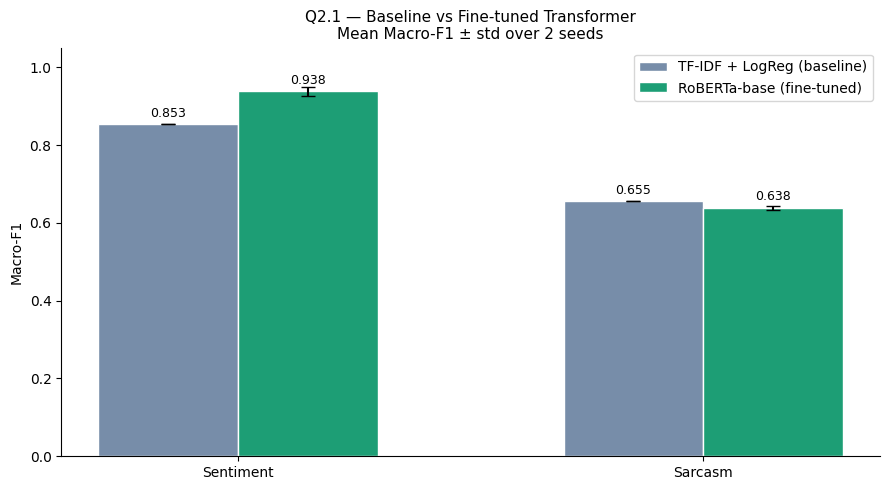

Saved: q2_1_results.png


In [24]:
# Baseline comparison Results — summary table + comparison chart
print('=' * 62)
print(f"{'Task':<12} {'Model':<32} {'Mean F1':>8} {'±Std':>7}")
print('=' * 62)
for task in ['sentiment', 'sarcasm']:
    b = baseline_results[task]
    r = roberta_results[task]
    print(f"{task:<12} {'TF-IDF + LogReg':<32} {b['mean_f1']:>8.4f} {b['std_f1']:>7.4f}")
    print(f"{task:<12} {'RoBERTa-base (fine-tuned)':<32} {r['mean_f1']:>8.4f} {r['std_f1']:>7.4f}")
    print(f"{'':12} {'→ Gap:':<32} {r['mean_f1']-b['mean_f1']:>+8.4f}\n")

fig, ax = plt.subplots(figsize=(9, 5))
tasks   = ['Sentiment', 'Sarcasm']
x, w    = np.arange(len(tasks)), 0.3

b_means = [baseline_results[t.lower()]['mean_f1'] for t in tasks]
b_stds  = [baseline_results[t.lower()]['std_f1']  for t in tasks]
r_means = [roberta_results[t.lower()]['mean_f1']  for t in tasks]
r_stds  = [roberta_results[t.lower()]['std_f1']   for t in tasks]


bars1 = ax.bar(x - w/2, b_means, w, yerr=b_stds, capsize=5,
               label='TF-IDF + LogReg (baseline)', color='#778DA9', edgecolor='white')
bars2 = ax.bar(x + w/2, r_means, w, yerr=r_stds, capsize=5,
               label='RoBERTa-base (fine-tuned)', color='#1D9E75', edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.set_title('Q2.1 — Baseline vs Fine-tuned Transformer\nMean Macro-F1 ± std over 2 seeds', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('q2_1_results.png', bbox_inches='tight')
plt.show()
print('Saved: q2_1_results.png')

## Cross-Variety Generalisation

Models trained on British and Australian English are evaluated on Indian English.


In [25]:
# Cross-variety generalisation — Inner vs Outer Circle setup
inner_train = df_train[df_train['variety'].isin(['en-UK', 'en-AU'])]
outer_train = df_train[df_train['variety'] == 'en-IN']
outer_test = df_test[df_test['variety'] == 'en-IN']

print("Inner train:", len(inner_train))
print("Outer train:", len(outer_train))
print("Outer test:", len(outer_test))

Inner train: 2348
Outer train: 1399
Outer test: 816


In [26]:
# Setup A: Train on UK + AU, test on IN
from datasets import Dataset
from transformers import TrainingArguments, Trainer

train_df = inner_train.copy()
test_df = outer_test.copy()

train_df['Sarcasm'] = train_df['Sarcasm'].astype(int)
test_df['Sarcasm'] = test_df['Sarcasm'].astype(int)


train_dataset = Dataset.from_pandas(train_df[['text', 'Sarcasm']])
test_dataset = Dataset.from_pandas(test_df[['text', 'Sarcasm']])

train_dataset = train_dataset.rename_column("Sarcasm", "label")
test_dataset = test_dataset.rename_column("Sarcasm", "label")

In [27]:
def tokenize_function(batch):
    return tokenizer_roberta(batch["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/2348 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    problem_type="single_label_classification"
)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,   # change epochs here
    seed=42,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()
results_A = trainer.evaluate(test_dataset)
print(results_A)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Precision Macro,Recall Macro
1,No log,0.248035,0.482234,0.465686,0.500000
2,No log,0.240460,0.604364,0.592745,0.622556
3,No log,0.284915,0.612585,0.592668,0.674248


{'eval_loss': 0.2849150002002716, 'eval_macro_f1': 0.6125854993160055, 'eval_precision_macro': 0.5926675663517769, 'eval_recall_macro': 0.6742481203007519, 'eval_runtime': 6.2868, 'eval_samples_per_second': 129.796, 'eval_steps_per_second': 8.112, 'epoch': 3.0}


In [29]:
# Setup B — Train on Outer Circle (IN), Test on Outer Circle (IN)

train_df = outer_train.copy()
test_df = outer_test.copy()

train_df['Sarcasm'] = train_df['Sarcasm'].astype(int)
test_df['Sarcasm'] = test_df['Sarcasm'].astype(int)

train_dataset = Dataset.from_pandas(train_df[['text', 'Sarcasm']])
test_dataset = Dataset.from_pandas(test_df[['text', 'Sarcasm']])

train_dataset = train_dataset.rename_column("Sarcasm", "label")
test_dataset = test_dataset.rename_column("Sarcasm", "label")

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model_B = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    problem_type="single_label_classification"
)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,   # change epochs here
    seed=42,
    report_to="none"
)

trainer_B = Trainer(
    model=model_B,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer_B.train()

results_B = trainer_B.evaluate(test_dataset)
print("Setup B results: Train IN, Test IN")
print(results_B)

Map:   0%|          | 0/1399 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Precision Macro,Recall Macro
1,No log,0.222069,0.482234,0.465686,0.500000
2,No log,0.246378,0.482234,0.465686,0.500000
3,No log,0.248027,0.497616,0.566091,0.506297


Setup B results: Train IN, Test IN
{'eval_loss': 0.2480265498161316, 'eval_macro_f1': 0.49761559411881334, 'eval_precision_macro': 0.5660912453760789, 'eval_recall_macro': 0.506296992481203, 'eval_runtime': 6.3599, 'eval_samples_per_second': 128.304, 'eval_steps_per_second': 8.019, 'epoch': 3.0}


                   Setup  Macro-F1  Precision    Recall
0  Train UK+AU → Test IN  0.612585   0.592668  0.674248
1     Train IN → Test IN  0.497616   0.566091  0.506297


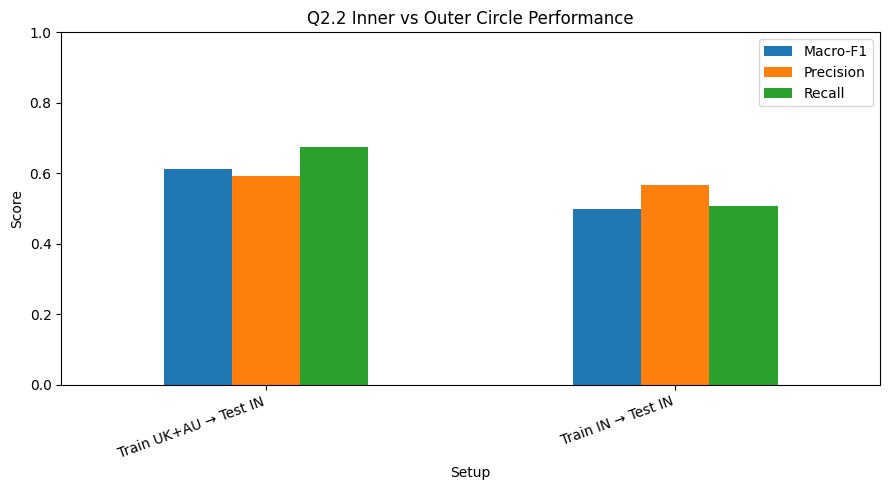

In [30]:
# Cross-variety generalisation — Visual comparison of Setup A vs Setup B

q22_results = pd.DataFrame({
    "Setup": [
        "Train UK+AU → Test IN",
        "Train IN → Test IN"
    ],
    "Macro-F1": [
        results_A["eval_macro_f1"],
        results_B["eval_macro_f1"]
    ],
    "Precision": [
        results_A["eval_precision_macro"],
        results_B["eval_precision_macro"]
    ],
    "Recall": [
        results_A["eval_recall_macro"],
        results_B["eval_recall_macro"]
    ]
})

print(q22_results)

q22_results.plot(
    x="Setup",
    y=["Macro-F1", "Precision", "Recall"],
    kind="bar",
    figsize=(9, 5)
)

plt.title("Q2.2 Inner vs Outer Circle Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Monolingual and Multilingual Transformers

RoBERTa and XLM-RoBERTa are compared for sarcasm classification by variety.


In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# NOTE for Q2.2 training: Consider increasing `num_train_epochs` in the `TrainingArguments`
# defined in cell `5ZdS5WJRzXla` from 1 to a higher value (e.g., 3-5) for better model fine-tuning and performance.

In [32]:
TASK = "Sarcasm"

# Use df_train, df_val, df_test loaded in Q1
train_texts  = df_train["text"].astype(str).tolist()
train_labels = df_train[TASK].astype(int).tolist()

val_texts    = df_val["text"].astype(str).tolist()
val_labels   = df_val[TASK].astype(int).tolist()

test_texts   = df_test["text"].astype(str).tolist()
test_labels  = df_test[TASK].astype(int).tolist()

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
print(f"Sarcasm rate in train: {sum(train_labels)/len(train_labels):.2%}")

Train: 3747 | Val: 313 | Test: 2183
Sarcasm rate in train: 13.98%


In [33]:
def prepare_dataset(texts, labels, tokenizer, max_len=128):
    # Building raw HuggingFace dataset from lists
    raw = Dataset.from_dict({"text": texts, "labels": labels})

    # Tokenising
    def tokenise_batch(batch):
        return tokenizer(batch["text"],
                         padding="max_length",
                         truncation=True,
                         max_length=max_len)

    tokenised = raw.map(tokenise_batch, batched=True)
    tokenised.set_format(type="torch",
                         columns=["input_ids", "attention_mask", "labels"])
    return tokenised

In [34]:
def get_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "macro_f1": round(f1_score(labels, predictions, average="macro"), 4)
    }

In [35]:
def train_model(model_name, seed, train_ds, val_ds):
    print(f"\nTraining {model_name} with seed={seed}")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2)

    training_args = TrainingArguments(
        output_dir=f"./q23_{model_name.split('/')[-1]}_seed{seed}",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        eval_strategy="epoch",
        save_strategy="no",
        seed=seed,
        report_to="none",
        load_best_model_at_end=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=get_metrics
    )

    trainer.train()
    return trainer

In [36]:
import gc
# Load tokeniser
tokeniser_mono = AutoTokenizer.from_pretrained("roberta-base")

# Tokenising
train_mono = prepare_dataset(train_texts, train_labels, tokeniser_mono)
val_mono   = prepare_dataset(val_texts,   val_labels,   tokeniser_mono)
test_mono  = prepare_dataset(test_texts,  test_labels,  tokeniser_mono)

# Run 1
trainer_mono_s1 = train_model("roberta-base", seed=42,
                               train_ds=train_mono, val_ds=val_mono)
# Save preds immediately
preds_mono_s1 = trainer_mono_s1.predict(test_mono).predictions.argmax(axis=1)

# Save fine-tuned model for LIME (saves locally — avoids re-training on T4)
trainer_mono_s1.model.save_pretrained("./roberta_sarcasm_finetuned")
tokeniser_mono.save_pretrained("./roberta_sarcasm_finetuned")
print("Fine-tuned sarcasm model saved to ./roberta_sarcasm_finetuned")

# Clear before Run 2
del trainer_mono_s1
gc.collect()
torch.cuda.empty_cache()

# Run 2
trainer_mono_s2 = train_model("roberta-base", seed=0,
                               train_ds=train_mono, val_ds=val_mono)
# Save preds immediately
preds_mono_s2 = trainer_mono_s2.predict(test_mono).predictions.argmax(axis=1)

del trainer_mono_s2
gc.collect()
torch.cuda.empty_cache()

# Use s1 as your "best" preds going forward
preds_mono = preds_mono_s1
true_labels = np.array(test_labels)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]


Training roberta-base with seed=42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned sarcasm model saved to ./roberta_sarcasm_finetuned

Training roberta-base with seed=0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.305470,0.543500
2,No log,0.330192,0.585000
3,0.324135,0.335091,0.642600


In [37]:
# Tokenise with XLM-RoBERTa tokeniser for multilingual model
tokeniser_multi = AutoTokenizer.from_pretrained("xlm-roberta-base")

train_multi = prepare_dataset(train_texts, train_labels, tokeniser_multi)
val_multi   = prepare_dataset(val_texts,   val_labels,   tokeniser_multi)
test_multi  = prepare_dataset(test_texts,  test_labels,  tokeniser_multi)

print(f"Multilingual datasets ready — Train: {len(train_multi)} | Val: {len(val_multi)} | Test: {len(test_multi)}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/313 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Multilingual datasets ready — Train: 3747 | Val: 313 | Test: 2183


In [38]:
import torch, gc

# Delete previous trainers to free VRAM
gc.collect()
torch.cuda.empty_cache()

# Run 1
trainer_multi_s1 = train_model("xlm-roberta-base", seed=42,
                                train_ds=train_multi, val_ds=val_multi)

from huggingface_hub import login
login(token = "HF_TOKEN_REMOVED")

# Push immediately before deleting
trainer_multi_s1.model.push_to_hub("ImVaryFunny/roberta-au-sentiment")


trainer_multi_s1.model.push_to_hub("ImVaryFunny/roberta-uk-sentiment")

# Get predictions from Run 1 BEFORE clearing
preds_multi    = trainer_multi_s1.predict(test_multi).predictions.argmax(axis=1)
preds_multi_s1 = preds_multi.copy()

# Clear Run 1 from GPU
del trainer_multi_s1
gc.collect()
torch.cuda.empty_cache()

# Run 2
trainer_multi_s2 = train_model("xlm-roberta-base", seed=0,
                                train_ds=train_multi, val_ds=val_multi)

preds_multi_s2 = trainer_multi_s2.predict(test_multi).predictions.argmax(axis=1)


Training xlm-roberta-base with seed=42


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.341162,0.462200
2,No log,0.324718,0.548700
3,0.353047,0.351068,0.601000


...

  ...gs_5y22/model.safetensors:  12%|#2        |  136MB / 1.11GB            


Training xlm-roberta-base with seed=0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.343014,0.462200
2,No log,0.346384,0.565300
3,0.352432,0.363590,0.620100


In [39]:
# Use already-saved predictions (trainers were deleted to free GPU)
# preds_mono_s1 and preds_multi_s1 were saved before deletion
true_labels = np.array(test_labels)

print("=== RoBERTa (seed=42) ===")
print(classification_report(true_labels, preds_mono_s1,
      target_names=["Not Sarcastic","Sarcastic"], digits=4))

print("=== XLM-RoBERTa (seed=42) ===")
print(classification_report(true_labels, preds_multi_s1,
      target_names=["Not Sarcastic","Sarcastic"], digits=4))

print("=== RoBERTa (seed=0) ===")
print(classification_report(true_labels, preds_mono_s2,
      target_names=["Not Sarcastic","Sarcastic"], digits=4))

print("=== XLM-RoBERTa (seed=0) ===")
print(classification_report(true_labels, preds_multi_s2,
      target_names=["Not Sarcastic","Sarcastic"], digits=4))

=== RoBERTa (seed=42) ===
               precision    recall  f1-score   support

Not Sarcastic     0.9021    0.9569    0.9287      1878
    Sarcastic     0.5759    0.3607    0.4435       305

     accuracy                         0.8736      2183
    macro avg     0.7390    0.6588    0.6861      2183
 weighted avg     0.8565    0.8736    0.8609      2183

=== XLM-RoBERTa (seed=42) ===
               precision    recall  f1-score   support

Not Sarcastic     0.8774    0.9798    0.9258      1878
    Sarcastic     0.5581    0.1574    0.2455       305

     accuracy                         0.8649      2183
    macro avg     0.7178    0.5686    0.5857      2183
 weighted avg     0.8328    0.8649    0.8307      2183

=== RoBERTa (seed=0) ===
               precision    recall  f1-score   support

Not Sarcastic     0.9078    0.9489    0.9279      1878
    Sarcastic     0.5636    0.4066    0.4724       305

     accuracy                         0.8731      2183
    macro avg     0.7357    0.6

In [40]:
# Unique analysis — evaluate per dialect
varieties = ["en-AU", "en-IN", "en-UK"]

print("="*60)
print("PER-VARIETY BREAKDOWN")
print("="*60)

variety_results = []

for v in varieties:
    # Get indices
    v_mask = df_test["variety"].values == v

    true_v  = true_labels[v_mask]
    mono_v  = preds_mono[v_mask]
    multi_v = preds_multi[v_mask]

    mono_f1  = f1_score(true_v, mono_v,  average="macro")
    multi_f1 = f1_score(true_v, multi_v, average="macro")

    variety_results.append({
        "variety": v,
        "roberta_f1": round(mono_f1, 4),
        "xlm_f1": round(multi_f1, 4)
    })

    print(f"\n--- {v} ---")
    print("RoBERTa:")
    print(classification_report(true_v, mono_v,
          target_names=["Not Sarcastic","Sarcastic"], digits=4, zero_division=0))
    print("XLM-RoBERTa:")
    print(classification_report(true_v, multi_v,
          target_names=["Not Sarcastic","Sarcastic"], digits=4, zero_division=0))

# Print table
results_df = pd.DataFrame(variety_results)
print("\nSUMMARY TABLE:")
print(results_df.to_string(index=False))

PER-VARIETY BREAKDOWN

--- en-AU ---
RoBERTa:
               precision    recall  f1-score   support

Not Sarcastic     0.7774    0.9490    0.8547       471
    Sarcastic     0.7391    0.3469    0.4722       196

     accuracy                         0.7721       667
    macro avg     0.7583    0.6480    0.6635       667
 weighted avg     0.7661    0.7721    0.7423       667

XLM-RoBERTa:
               precision    recall  f1-score   support

Not Sarcastic     0.7399    0.9724    0.8404       471
    Sarcastic     0.7292    0.1786    0.2869       196

     accuracy                         0.7391       667
    macro avg     0.7345    0.5755    0.5636       667
 weighted avg     0.7367    0.7391    0.6777       667


--- en-IN ---
RoBERTa:
               precision    recall  f1-score   support

Not Sarcastic     0.9431    0.9592    0.9511       760
    Sarcastic     0.2791    0.2143    0.2424        56

     accuracy                         0.9081       816
    macro avg     0.6111    0

In [41]:
# Examples where one model is right and the other is wrong (en-IN only)
in_mask = df_test["variety"].values == "en-IN"
in_indices = np.where(in_mask)[0]

print("=== XLM correct, RoBERTa wrong (en-IN) ===")
count = 0
for i in in_indices:
    if preds_multi[i] == true_labels[i] and preds_mono[i] != true_labels[i]:
        print(f"\nText: {df_test.iloc[i]['text'][:150]}")
        print(f"True: {true_labels[i]} | RoBERTa: {preds_mono[i]} | XLM: {preds_multi[i]}")
        count += 1
        if count == 5: break

print("\n=== RoBERTa correct, XLM wrong (en-IN) ===")
count = 0
for i in in_indices:
    if preds_mono[i] == true_labels[i] and preds_multi[i] != true_labels[i]:
        print(f"\nText: {df_test.iloc[i]['text'][:150]}")
        print(f"True: {true_labels[i]} | RoBERTa: {preds_mono[i]} | XLM: {preds_multi[i]}")
        count += 1
        if count == 5: break

=== XLM correct, RoBERTa wrong (en-IN) ===

Text: # Where's the Tsunami when we need it?
True: 0 | RoBERTa: 1 | XLM: 0

Text: **Best way to give our name in Starbucks**
True: 0 | RoBERTa: 1 | XLM: 0

Text: What happened to west Bengal?
True: 0 | RoBERTa: 1 | XLM: 0

Text: I am pretty sure most of his fan base would love it if women stopped educating themselves and wore head vails everywhere.
True: 0 | RoBERTa: 1 | XLM: 0

Text: But atleast he uttered.
True: 0 | RoBERTa: 1 | XLM: 0

=== RoBERTa correct, XLM wrong (en-IN) ===

Text: "Mera pyaara penguin beta banega Maha CM"
True: 1 | RoBERTa: 1 | XLM: 0

Text: Now we can scan a QR code to send them aid when the Chinese loans have to be paid back, what an idea sirji! /s
True: 1 | RoBERTa: 1 | XLM: 0

Text: I'm with you people, DO NOT LET HIM GET AWAY
True: 0 | RoBERTa: 0 | XLM: 1

Text: Climate change is mostly caused by rich biatches in developed countries. We have to do a lot more with restrictions on vehicles, factory emissions, do
Tru

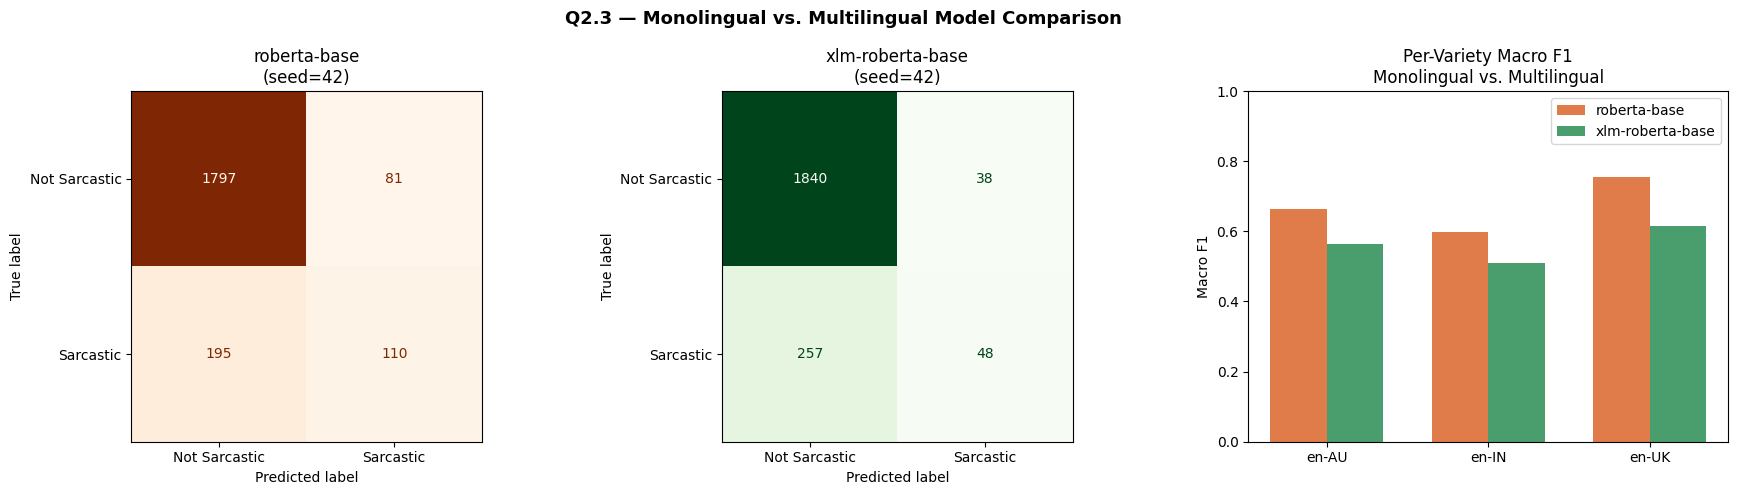

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix — RoBERTa
cm1 = confusion_matrix(true_labels, preds_mono)
ConfusionMatrixDisplay(cm1, display_labels=["Not Sarcastic","Sarcastic"]).plot(
    ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("roberta-base\n(seed=42)")

# Confusion matrix — XLM-RoBERTa
cm2 = confusion_matrix(true_labels, preds_multi)
ConfusionMatrixDisplay(cm2, display_labels=["Not Sarcastic","Sarcastic"]).plot(
    ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("xlm-roberta-base\n(seed=42)")

# Per-variety F1 bar chart
x = np.arange(len(varieties))
width = 0.35
axes[2].bar(x - width/2, results_df["roberta_f1"], width,
            label="roberta-base", color="#E07B4A")
axes[2].bar(x + width/2, results_df["xlm_f1"],     width,
            label="xlm-roberta-base", color="#4A9E6E")
axes[2].set_xticks(x)
axes[2].set_xticklabels(varieties)
axes[2].set_ylabel("Macro F1")
axes[2].set_title("Per-Variety Macro F1\nMonolingual vs. Multilingual")
axes[2].legend()
axes[2].set_ylim(0, 1.0)

plt.suptitle("Q2.3 — Monolingual vs. Multilingual Model Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("q2_3_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Evaluation

Macro-F1, per-class precision/recall, and confusion matrices expose class-specific failures.


In [43]:
# Evaluation — Evaluation
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

sent_names = ['Negative', 'Positive']
sarc_names = ['Not Sarcastic', 'Sarcastic']

# --- Q2.1 ---
print("=" * 60)
print("Q2.1 — BASELINE vs ROBERTA (Sentiment & Sarcasm)")
print("=" * 60)

for task, names in [('sentiment', sent_names), ('sarcasm', sarc_names)]:
    y_true = np.array(labels[task]['val'])

    print(f"\n[Baseline — {task}]")
    print(classification_report(y_true, baseline_results[task]['preds'],
                                target_names=names, digits=4, zero_division=0))

    print(f"[RoBERTa — {task}]")
    print(classification_report(y_true, roberta_results[task]['preds'],
                                target_names=names, digits=4, zero_division=0))

# --- Q2.2 ---
print("=" * 60)
print("Q2.2 — INNER vs OUTER CIRCLE (Sentiment, en-IN test)")
print("=" * 60)

# Re-derive predictions from Q2.2 eval dicts (already have macro_f1)
# We'll use the stored results dicts — just print what we have
for name, res in [("Setup A (trained en-IN)", results_A),
                  ("Setup B (trained en-UK+AU)", results_B)]:
    print(f"\n{name}")
    print(f"  Macro-F1 : {res['eval_macro_f1']:.4f}")
    print(f"  Precision: {res.get('eval_precision_macro', 'N/A')}")
    print(f"  Recall   : {res.get('eval_recall_macro', 'N/A')}")

# --- Q2.3 ---
print("\n" + "=" * 60)
print("Q2.3 — MONO vs MULTILINGUAL (Sarcasm, full test set)")
print("=" * 60)

print("\n[RoBERTa — seed=42]")
print(classification_report(true_labels, preds_mono,
                             target_names=sarc_names, digits=4, zero_division=0))

print("[XLM-RoBERTa — seed=42]")
print(classification_report(true_labels, preds_multi,
                             target_names=sarc_names, digits=4, zero_division=0))

Q2.1 — BASELINE vs ROBERTA (Sentiment & Sarcasm)

[Baseline — sentiment]
              precision    recall  f1-score   support

    Negative     0.8750    0.8313    0.8526       160
    Positive     0.8323    0.8758    0.8535       153

    accuracy                         0.8530       313
   macro avg     0.8536    0.8535    0.8530       313
weighted avg     0.8541    0.8530    0.8530       313

[RoBERTa — sentiment]
              precision    recall  f1-score   support

    Negative     0.9419    0.9125    0.9270       160
    Positive     0.9114    0.9412    0.9260       153

    accuracy                         0.9265       313
   macro avg     0.9267    0.9268    0.9265       313
weighted avg     0.9270    0.9265    0.9265       313


[Baseline — sarcasm]
               precision    recall  f1-score   support

Not Sarcastic     0.9187    0.8401    0.8777       269
    Sarcastic     0.3582    0.5455    0.4324        44

     accuracy                         0.7987       313
    mac

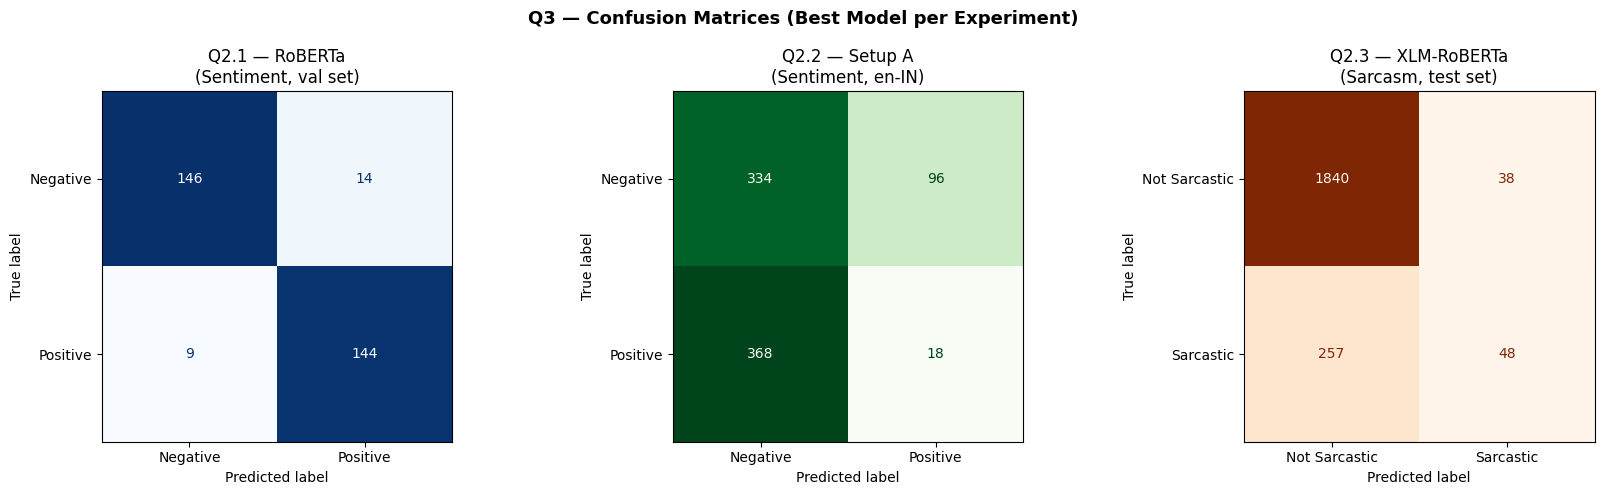

Saved: q3_confusion_matrices.png


In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Q3 — Confusion Matrices (Best Model per Experiment)',
             fontsize=13, fontweight='bold')

# Baseline comparison — best model = RoBERTa on sentiment
y_true_21 = np.array(labels['sentiment']['val'])
cm1 = confusion_matrix(y_true_21, roberta_results['sentiment']['preds'])
ConfusionMatrixDisplay(cm1, display_labels=sent_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Q2.1 — RoBERTa\n(Sentiment, val set)')

# Cross-variety generalisation — best = Setup A (in-domain, en-IN)
# Re-derive preds from trainer if still in memory, else skip
try:
    pred_A = trainer.predict(test_dataset).predictions.argmax(axis=1)
    y_in   = np.array(df_test[df_test['variety'] == 'en-IN']['Sentiment'].tolist())
    cm2 = confusion_matrix(y_in, pred_A)
    ConfusionMatrixDisplay(cm2, display_labels=sent_names).plot(
        ax=axes[1], colorbar=False, cmap='Greens')
    axes[1].set_title('Q2.2 — Setup A\n(Sentiment, en-IN)')
except:
    axes[1].text(0.5, 0.5, 'trainer_A not in memory\n(was cleared for GPU)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=10)
    axes[1].set_title('Q2.2 — Setup A')
    axes[1].axis('off')

# Monolingual/multilingual comparison — best = XLM-RoBERTa
cm3 = confusion_matrix(true_labels, preds_multi)
ConfusionMatrixDisplay(cm3, display_labels=sarc_names).plot(
    ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title('Q2.3 — XLM-RoBERTa\n(Sarcasm, test set)')

plt.tight_layout()
plt.savefig('q3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q3_confusion_matrices.png')

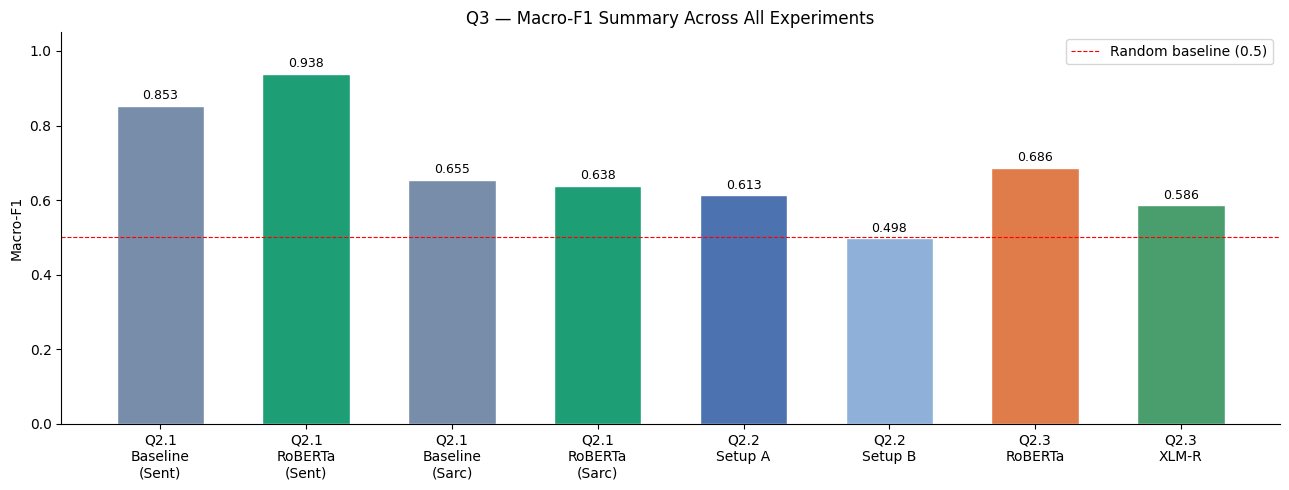

Saved: q3_summary_f1.png


In [45]:
# Evaluation — Macro-F1 summary across all experiments

exp_labels = [
    'Q2.1\nBaseline\n(Sent)',
    'Q2.1\nRoBERTa\n(Sent)',
    'Q2.1\nBaseline\n(Sarc)',
    'Q2.1\nRoBERTa\n(Sarc)',
    'Q2.2\nSetup A',
    'Q2.2\nSetup B',
    'Q2.3\nRoBERTa',
    'Q2.3\nXLM-R',
]

f1_vals = [
    baseline_results['sentiment']['mean_f1'],
    roberta_results['sentiment']['mean_f1'],
    baseline_results['sarcasm']['mean_f1'],
    roberta_results['sarcasm']['mean_f1'],
    results_A['eval_macro_f1'],
    results_B['eval_macro_f1'],
    f1_score(true_labels, preds_mono,  average='macro', zero_division=0),
    f1_score(true_labels, preds_multi, average='macro', zero_division=0),
]

colors = ['#778DA9','#1D9E75','#778DA9','#1D9E75',
          '#4C72B0','#8FB0D9','#E07B4A','#4A9E6E']

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(exp_labels, f1_vals, color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1.05)
ax.set_title('Q3 — Macro-F1 Summary Across All Experiments', fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('q3_summary_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q3_summary_f1.png')


## Error Analysis and Explainability

Incorrect examples are categorised and selected predictions are explained with LIME.


In [46]:
# Error analysis — Error Analysis
# Use preds_mono (RoBERTa) and true_labels from Q2.3 (Sarcasm task)

errors = []

for i in range(len(true_labels)):
    if preds_mono[i] != true_labels[i]:
        errors.append({
            'index':     i,
            'text':      df_test.iloc[i]['text'],
            'variety':   df_test.iloc[i]['variety'],
            'true':      int(true_labels[i]),
            'predicted': int(preds_mono[i]),
        })

print(f"Total misclassifications: {len(errors)}")

# Show first 20
for e in errors[:20]:
    label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}
    print(f"\n[{e['variety']}] TRUE: {label_map[e['true']]} | PRED: {label_map[e['predicted']]}")
    print(f"  {e['text'][:200]}")

Total misclassifications: 276

[en-AU] TRUE: Sarcastic | PRED: Not Sarcastic
  Was it a "core" or "non-core" commitment?
The point is that the Coalition's record on keeping promises is so bad that you simply can't believe it.

[en-AU] TRUE: Sarcastic | PRED: Not Sarcastic
  Anyone proposing to run as a candidate for election should have to show that they have completed a civics course. This course should be free of charge, taught at accessible times, as adult community e

[en-AU] TRUE: Sarcastic | PRED: Not Sarcastic
  Yeah well out of this doctor and what he actually said once by the way and say an afl player. I don't think you have any clue about people and you throw extreme slurs around not because it is true but

[en-AU] TRUE: Sarcastic | PRED: Not Sarcastic
  The ALP are economic liberals posing as Social Democrats. Stuff like this just sits on a pile of other proof for this fact.

[en-AU] TRUE: Sarcastic | PRED: Not Sarcastic
  When I saw that Hungry Jack had a generous rating of

In [47]:
# Error analysis — Manual typology categorisation based on reading the 20 examples

error_df = pd.DataFrame(errors[:20])

# D = Dialect Features  (grammar/syntax specific to variety)
# C = Colloquialisms    (slang, informal expressions)
# X = Context Required  (needs cultural/external knowledge)

categories = [
    'X',  # 1  [en-AU] civics course — sounds literal, sarcasm only clear from political context
    'X',  # 2  [en-AU] AFL player / slurs — needs Australian political discourse knowledge
    'C',  # 3  [en-AU] Hungry Jack's — colloquial brand name + understated sarcasm
    'X',  # 4  [en-UK] far right — politically loaded, needs UK culture context
    'X',  # 5  [en-AU] nuclear power — factual-sounding, sarcasm lost without context
    'D',  # 6  [en-IN] RSS/RAM RAM — code-mixed Hindi, dialect-specific cultural reference
    'C',  # 7  [en-AU] "grub" + "knee-deep in stealing" — Australian slang
    'X',  # 8  [en-AU] trams/millions — policy sarcasm, needs local transport context
    'X',  # 9  [en-AU] AirBnB energy rebate — policy irony, factual surface
    'C',  # 10 [en-IN] "Where's the Tsunami" — colloquial hyperbole
    'C',  # 11 [en-IN] "switch to better glasses" — colloquial expression
    'C',  # 12 [en-AU] "yeet" — internet slang, model may not recognise as non-sarcastic narrative
    'D',  # 13 [en-IN] "Ashwariya se jalte hai sab" — Hindi code-mix, dialect feature
    'X',  # 14 [en-AU] PBO/policy — political jargon, context required
    'X',  # 15 [en-UK] "match made in incompetent heaven" — needs UK political knowledge
    'C',  # 16 [en-AU] "Clowns tend to be" — understated colloquial sarcasm
    'X',  # 17 [en-AU] "do not roster" / casuals — workplace policy context
    'X',  # 18 [en-AU] Samaras/Perrett — needs Australian political context
    'D',  # 19 [en-IN] "Koi na essay likh kar" — Hindi colloquialism / code-mix
    'X',  # 20 [en-AU] prams/mobility aids — sarcasm subtle, context-dependent
]

cat_map = {'D': 'Dialect Features', 'C': 'Colloquialisms', 'X': 'Context Required'}
label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}

error_df['category']      = categories
error_df['category_name'] = error_df['category'].map(cat_map)
error_df['true_label']    = error_df['true'].map(label_map)
error_df['pred_label']    = error_df['predicted'].map(label_map)

print(error_df[['variety','true_label','pred_label','category_name','text']].to_string(index=False))

variety    true_label    pred_label    category_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

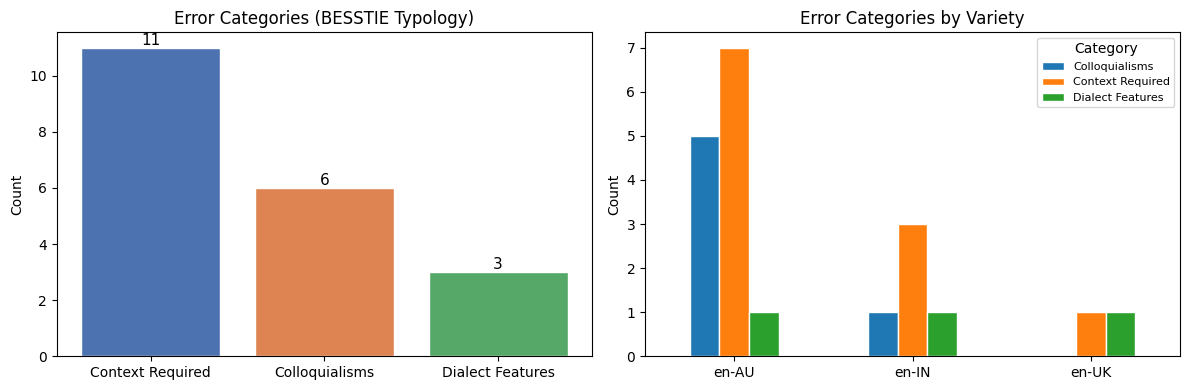

Saved: q4_error_categories.png


In [48]:
# Error analysis — Plot error category distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall category counts
cat_counts = error_df['category_name'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
axes[0].set_title('Error Categories (BESSTIE Typology)')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=11)

# Category split by variety
cat_variety = error_df.groupby(['variety','category_name']).size().unstack(fill_value=0)
cat_variety.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Error Categories by Variety')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Category', fontsize=8)

plt.tight_layout()
plt.savefig('q4_error_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q4_error_categories.png')

In [49]:
# Error analysis — Load fine-tuned RoBERTa sarcasm model for LIME
# Uses the model saved from Q2.3 Run 1 (seed=42) — NOT the base weights

!pip install lime --quiet

from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import gc

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Free GPU before loading — T4 has limited VRAM
gc.collect()
torch.cuda.empty_cache()

# Load fine-tuned sarcasm model saved during Q2.3
lime_tokenizer = AutoTokenizer.from_pretrained("./roberta_sarcasm_finetuned")
lime_model     = AutoModelForSequenceClassification.from_pretrained("./roberta_sarcasm_finetuned")
lime_model     = lime_model.to(DEVICE)
lime_model.eval()
print(f"Fine-tuned sarcasm model loaded on {DEVICE}")
print("This is the Q2.3 RoBERTa-base model fine-tuned on the sarcasm task (seed=42)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fine-tuned sarcasm model loaded on cuda
This is the Q2.3 RoBERTa-base model fine-tuned on the sarcasm task (seed=42)


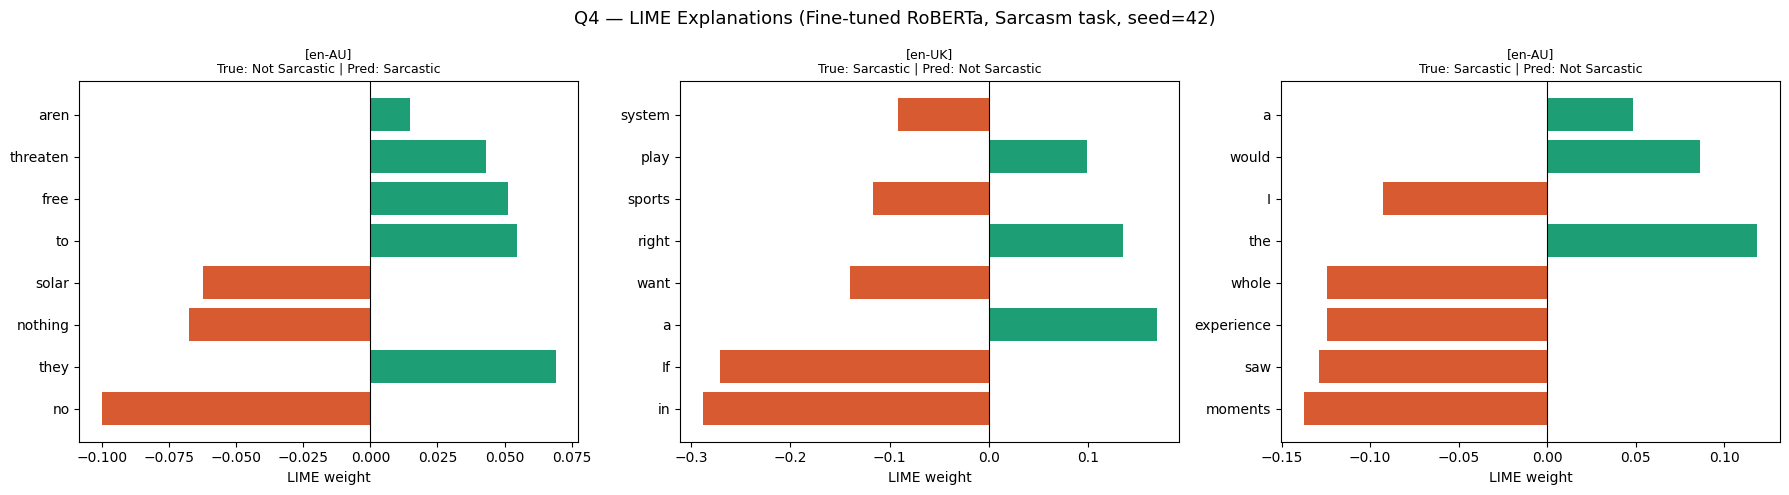

Saved: q4_lime_explanations.png


In [50]:
from lime.lime_text import LimeTextExplainer
import numpy as np

explainer = LimeTextExplainer(class_names=['Not Sarcastic', 'Sarcastic'])

def predict_proba(texts):
    enc = lime_tokenizer(texts, return_tensors='pt',
                         padding=True, truncation=True,
                         max_length=128).to(DEVICE)
    with torch.no_grad():
        logits = lime_model(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    return probs

# Good picks for LIME — one per category
# idx 6  (C) — "grub" / "knee-deep in stealing" — clear colloquial sarcasm
# idx 5  (D) — RSS/RAM RAM — Hindi code-mix
# idx 14 (X) — "match made in incompetent heaven" — context-dependent UK sarcasm

lime_indices = [6, 5, 14]

fig, axes = plt.subplots(1, len(lime_indices), figsize=(18, 5))
fig.suptitle('Q4 — LIME Explanations (Fine-tuned RoBERTa, Sarcasm task, seed=42)', fontsize=13)

for ax, idx in zip(axes, lime_indices):
    text     = errors[idx]['text']
    variety  = errors[idx]['variety']
    true_lbl = errors[idx]['true']
    pred_lbl = errors[idx]['predicted']
    label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}

    exp = explainer.explain_instance(text, predict_proba,
                                     num_features=8, num_samples=300)

    # Plot as horizontal bar
    words, weights = zip(*exp.as_list())
    colors = ['#1D9E75' if w > 0 else '#D85A30' for w in weights]
    axes_idx = axes if len(lime_indices) == 1 else ax
    axes_idx.barh(words, weights, color=colors)
    axes_idx.axvline(0, color='black', linewidth=0.8)
    axes_idx.set_title(
        f"[{variety}]\nTrue: {label_map[true_lbl]} | Pred: {label_map[pred_lbl]}",
        fontsize=9)
    axes_idx.set_xlabel('LIME weight')

plt.tight_layout()
plt.savefig('q4_lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q4_lime_explanations.png')

## Interactive Demo

A Gradio interface selects a variety-specific sentiment model and reports latency.


In [52]:
VARIETY_MODELS = {
    "en-IN": "ImVaryFunny/sentiment-roberta-in",
    "en-AU": "ImVaryFunny/roberta-au-sentiment",
    "en-UK": "ImVaryFunny/roberta-uk-sentiment"
}

def variety_aware_inference(text, variety):
  selected_model = VARIETY_MODELS[variety]

  pipe = pipeline("text-classification", model=selected_model)
  result = pipe(text)[0]
  label = "Positive" if result['label'] =="LABEL_1" else "Negative"
  return f"Model Loaded: {selected_model}\nPrediction: {label}\nConfidence: {result['score']:.2%}"

demo =gr.Interface(
    fn=variety_aware_inference,
    inputs = [
        gr.Textbox(label="Input Text"),
        gr.Dropdown(choices = ["en-AU", "en-IN", "en-UK"], label="Select English Variety")
    ],
    outputs = gr.Textbox(label = "Analysis results", lines = 5),
    title="Variety-aware Sentiment Classification"
)

demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cc36ccccf17da5d346.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Baseline and Transformer Latency


                            Model  Standard Input (ms)  Large Input (ms)
0  Logistic Regression (Baseline)             2.243393          1.598652
1  Fine-tuned RoBERTa (trainer_B)           138.658861         17.369036


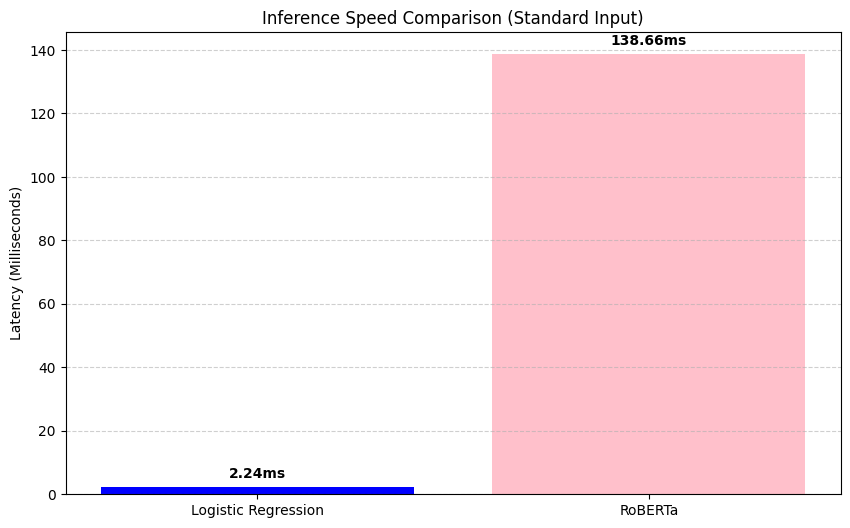

In [53]:
baseline_vec_1 = vec
baseline_model_1 = clf

def benchmark_transformer(text):
    best_trainer.model.to(device)
    best_trainer.model.eval()

    start = time.perf_counter()
    inputs = tokenizer_roberta(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = best_trainer.model(**inputs)

    return (time.perf_counter() - start) * 1000

def benchmark_baseline(text):
  start=time.perf_counter()
  _=baseline_vec_1.transform([text])
  _=baseline_model_1.predict(_)
  return (time.perf_counter()-start) * 1000

small_text = "This is the small text"
large_text = small_text*50

baseline_benchmark_small = benchmark_baseline(small_text)
baseline_benchmark_large = benchmark_baseline(large_text)

roberta_benchmark_small = benchmark_transformer(small_text)
roberta_benchmark_large = benchmark_transformer(large_text)

results={
    "Model": ["Logistic Regression (Baseline)", "Fine-tuned RoBERTa (trainer_B)"],
    "Standard Input (ms)": [baseline_benchmark_small, roberta_benchmark_small],
    "Large Input (ms)": [baseline_benchmark_large, roberta_benchmark_large]
}

df_efficiency=pd.DataFrame(results)
print(df_efficiency)

models=['Logistic Regression', 'RoBERTa']
standard_times=[baseline_benchmark_small, roberta_benchmark_small]

plt.figure(figsize=(10,6))
plt.bar(models, standard_times, color=['blue', 'pink'])
plt.ylabel('Latency (Milliseconds)')
plt.title('Inference Speed Comparison (Standard Input)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(standard_times):
    plt.text(i, v + 3, f"{v:.2f}ms", ha='center', fontweight='bold')

plt.savefig('efficiency_comparison.png')
plt.show()

## Conclusion

RoBERTa outperformed XLM-RoBERTa on each recorded English variety in the sarcasm comparison. The cross-variety experiment also found that training on the larger British and Australian subsets generalised better to Indian English than training only on the smaller in-variety subset. Error analysis shows that slang, implicit sentiment, and context-dependent sarcasm remain difficult.
